In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from my_functions import *

sns.set_theme()
gc.enable()

In [2]:
prev_data=pd.read_csv('previous_application.csv')
prev_data.shape

(1670214, 37)

In [3]:
prev_data.dtypes

SK_ID_PREV                       int64
SK_ID_CURR                       int64
NAME_CONTRACT_TYPE              object
AMT_ANNUITY                    float64
AMT_APPLICATION                float64
AMT_CREDIT                     float64
AMT_DOWN_PAYMENT               float64
AMT_GOODS_PRICE                float64
WEEKDAY_APPR_PROCESS_START      object
HOUR_APPR_PROCESS_START          int64
FLAG_LAST_APPL_PER_CONTRACT     object
NFLAG_LAST_APPL_IN_DAY           int64
RATE_DOWN_PAYMENT              float64
RATE_INTEREST_PRIMARY          float64
RATE_INTEREST_PRIVILEGED       float64
NAME_CASH_LOAN_PURPOSE          object
NAME_CONTRACT_STATUS            object
DAYS_DECISION                    int64
NAME_PAYMENT_TYPE               object
CODE_REJECT_REASON              object
NAME_TYPE_SUITE                 object
NAME_CLIENT_TYPE                object
NAME_GOODS_CATEGORY             object
NAME_PORTFOLIO                  object
NAME_PRODUCT_TYPE               object
CHANNEL_TYPE             

In [4]:
prev_data.isnull().sum()*100/prev_data.shape[0]

SK_ID_PREV                      0.000000
SK_ID_CURR                      0.000000
NAME_CONTRACT_TYPE              0.000000
AMT_ANNUITY                    22.286665
AMT_APPLICATION                 0.000000
AMT_CREDIT                      0.000060
AMT_DOWN_PAYMENT               53.636480
AMT_GOODS_PRICE                23.081773
WEEKDAY_APPR_PROCESS_START      0.000000
HOUR_APPR_PROCESS_START         0.000000
FLAG_LAST_APPL_PER_CONTRACT     0.000000
NFLAG_LAST_APPL_IN_DAY          0.000000
RATE_DOWN_PAYMENT              53.636480
RATE_INTEREST_PRIMARY          99.643698
RATE_INTEREST_PRIVILEGED       99.643698
NAME_CASH_LOAN_PURPOSE          0.000000
NAME_CONTRACT_STATUS            0.000000
DAYS_DECISION                   0.000000
NAME_PAYMENT_TYPE               0.000000
CODE_REJECT_REASON              0.000000
NAME_TYPE_SUITE                49.119754
NAME_CLIENT_TYPE                0.000000
NAME_GOODS_CATEGORY             0.000000
NAME_PORTFOLIO                  0.000000
NAME_PRODUCT_TYP

In [5]:
numerical_frame=prev_data.select_dtypes(exclude=object)
categorical_frame=prev_data.select_dtypes(include=object)
categorical_frame['SK_ID_PREV']=prev_data['SK_ID_PREV']
categorical_frame['SK_ID_CURR']=prev_data['SK_ID_CURR']

In [6]:
numerical_frame=numerical_frame[['SK_ID_CURR', 'SK_ID_PREV', 
                                 'AMT_DOWN_PAYMENT', 'CNT_PAYMENT',
                                 'RATE_DOWN_PAYMENT', 'SELLERPLACE_AREA']]
categorical_frame=categorical_frame[['SK_ID_CURR', 'SK_ID_PREV', 
                                     'CHANNEL_TYPE', 'CODE_REJECT_REASON',
                                     'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION']]


### Aggregation

#### Numerical

In [7]:
agg_data=numerical_frame.groupby(by='SK_ID_CURR').agg(func=['min', 'max', 'median'])
agg_data.columns=pd.Index(['_'.join(val) for val in agg_data.columns.to_flat_index()])
agg_data.drop(labels=['SK_ID_PREV_min', 'SK_ID_PREV_max', 'SK_ID_PREV_median'], axis=1, inplace=True)
agg_data.reset_index(inplace=True)
agg_data.shape

(338857, 13)

In [8]:
'''
adding target column
<main_data_id_target> contains target for each current loan
'''
main_data_id_target=pd.read_csv('application_train.csv',usecols=['SK_ID_CURR', 'TARGET']) 
agg_target=pd.merge(left=agg_data, right=main_data_id_target, on='SK_ID_CURR')
agg_target.shape

(291057, 14)

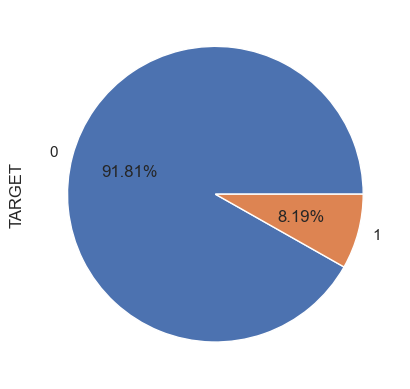

In [9]:
'''
distribution of target in the aggregated data
'''
agg_target['TARGET'].value_counts().plot.pie(autopct='%1.2f%%');

#### Categorical

##### CHANNEL_TYPE

In [10]:
categorical_frame['CHANNEL_TYPE'].isnull().sum()

0

In [11]:
categorical_frame['CHANNEL_TYPE'].value_counts()

Credit and cash offices       719968
Country-wide                  494690
Stone                         212083
Regional / Local              108528
Contact center                 71297
AP+ (Cash loan)                57046
Channel of corporate sales      6150
Car dealer                       452
Name: CHANNEL_TYPE, dtype: int64

In [12]:
temp1=categorical_frame[['SK_ID_CURR', 'CHANNEL_TYPE']].value_counts().unstack().fillna(0)
temp1.rename(columns=lambda x: 'CHANNEL_'+x, inplace=True)
temp1['TOTAL']=temp1.sum(axis=1)
temp1.reset_index(inplace=True)
temp1.head()

CHANNEL_TYPE,SK_ID_CURR,CHANNEL_AP+ (Cash loan),CHANNEL_Car dealer,CHANNEL_Channel of corporate sales,CHANNEL_Contact center,CHANNEL_Country-wide,CHANNEL_Credit and cash offices,CHANNEL_Regional / Local,CHANNEL_Stone,TOTAL
0,100001,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,100002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,100003,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,3.0
3,100004,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,100005,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0


In [13]:
agg_target=pd.merge(left=agg_target, right=temp1, on='SK_ID_CURR')
agg_target.shape

(291057, 23)

##### CODE_REJECT_REASON

In [14]:
categorical_frame['CODE_REJECT_REASON'].isnull().sum()

0

In [15]:
categorical_frame['CODE_REJECT_REASON'].value_counts()

XAP       1353093
HC         175231
LIMIT       55680
SCO         37467
CLIENT      26436
SCOFR       12811
XNA          5244
VERIF        3535
SYSTEM        717
Name: CODE_REJECT_REASON, dtype: int64

In [16]:
temp1=categorical_frame[['SK_ID_CURR', 'CODE_REJECT_REASON']].value_counts().unstack().fillna(0)
temp1.rename(columns=lambda x: 'REJECT_'+x, inplace=True)
temp1.reset_index(inplace=True)
temp1.head()

CODE_REJECT_REASON,SK_ID_CURR,REJECT_CLIENT,REJECT_HC,REJECT_LIMIT,REJECT_SCO,REJECT_SCOFR,REJECT_SYSTEM,REJECT_VERIF,REJECT_XAP,REJECT_XNA
0,100001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,100002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,100003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
3,100004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,100005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


In [17]:
agg_target=pd.merge(left=agg_target, right=temp1, on='SK_ID_CURR')
agg_target.shape

(291057, 32)

##### NAME_YIELD_GROUP

In [18]:
categorical_frame['NAME_YIELD_GROUP'].isnull().sum()

0

In [19]:
categorical_frame['NAME_YIELD_GROUP'].value_counts()

XNA           517215
middle        385532
high          353331
low_normal    322095
low_action     92041
Name: NAME_YIELD_GROUP, dtype: int64

In [20]:
temp1=categorical_frame[['SK_ID_CURR', 'NAME_YIELD_GROUP']].value_counts().unstack().fillna(0)
temp1.rename(columns=lambda x: 'YIELD_'+x, inplace=True)
temp1.reset_index(inplace=True)
temp1.head()

NAME_YIELD_GROUP,SK_ID_CURR,YIELD_XNA,YIELD_high,YIELD_low_action,YIELD_low_normal,YIELD_middle
0,100001,0.0,1.0,0.0,0.0,0.0
1,100002,0.0,0.0,0.0,1.0,0.0
2,100003,0.0,0.0,0.0,1.0,2.0
3,100004,0.0,0.0,0.0,0.0,1.0
4,100005,1.0,1.0,0.0,0.0,0.0


In [21]:
agg_target=pd.merge(left=agg_target, right=temp1, on='SK_ID_CURR')
agg_target.shape

(291057, 37)

##### PRODUCT_COMBINATION

In [22]:
categorical_frame['PRODUCT_COMBINATION'].isnull().sum()

346

In [23]:
categorical_frame['PRODUCT_COMBINATION'].value_counts()

Cash                              285990
POS household with interest       263622
POS mobile with interest          220670
Cash X-Sell: middle               143883
Cash X-Sell: low                  130248
Card Street                       112582
POS industry with interest         98833
POS household without interest     82908
Card X-Sell                        80582
Cash Street: high                  59639
Cash X-Sell: high                  59301
Cash Street: middle                34658
Cash Street: low                   33834
POS mobile without interest        24082
POS other with interest            23879
POS industry without interest      12602
POS others without interest         2555
Name: PRODUCT_COMBINATION, dtype: int64

In [24]:
temp1=categorical_frame[['SK_ID_CURR', 'PRODUCT_COMBINATION']].value_counts().unstack().fillna(0)
temp1.rename(columns=lambda x: 'PRODUCT_'+x, inplace=True)
temp1.reset_index(inplace=True)
temp1.head()

PRODUCT_COMBINATION,SK_ID_CURR,PRODUCT_Card Street,PRODUCT_Card X-Sell,PRODUCT_Cash,PRODUCT_Cash Street: high,PRODUCT_Cash Street: low,PRODUCT_Cash Street: middle,PRODUCT_Cash X-Sell: high,PRODUCT_Cash X-Sell: low,PRODUCT_Cash X-Sell: middle,PRODUCT_POS household with interest,PRODUCT_POS household without interest,PRODUCT_POS industry with interest,PRODUCT_POS industry without interest,PRODUCT_POS mobile with interest,PRODUCT_POS mobile without interest,PRODUCT_POS other with interest,PRODUCT_POS others without interest
0,100001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,100002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,100003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,100004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,100005,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [25]:
agg_target=pd.merge(left=agg_target, right=temp1, on='SK_ID_CURR')
agg_target.shape

(291057, 54)

## Analysis

In [27]:
# plot_all_hist_default_pct(agg_target, agg_target.columns)

In [29]:
# plot_all_numeric_kde(agg_target, agg_target.columns)

In [32]:
numerical_features=pd.Index(['SK_ID_CURR', 'TARGET', 'AMT_DOWN_PAYMENT_max',
                             'RATE_DOWN_PAYMENT_max', 'SELLERPLACE_AREA_max',
                             'REJECT_HC', 'YIELD_XNA', 'PRODUCT_Card Street',
                             'PRODUCT_Cash Street: high', 'PRODUCT_Cash X-Sell: low'])

numerical_frame=agg_target[numerical_features].copy()
numerical_frame.rename(columns={'PRODUCT_Card Street': 'PRODUCT_CARD_STREET', 'PRODUCT_Cash Street: high': 'PRODUCT_CASH_STREET_HIGH',
                                'PRODUCT_Cash X-Sell: low': 'PRODUCT_CASH_X_SELL_LOW'})
numerical_frame.shape, numerical_frame.columns.sort_values()

((291057, 10),
 Index(['AMT_DOWN_PAYMENT_max', 'PRODUCT_Card Street',
        'PRODUCT_Cash Street: high', 'PRODUCT_Cash X-Sell: low',
        'RATE_DOWN_PAYMENT_max', 'REJECT_HC', 'SELLERPLACE_AREA_max',
        'SK_ID_CURR', 'TARGET', 'YIELD_XNA'],
       dtype='object'))